# SXB Method Comparison (Single Shot) — 250424006

> Goal: run **two analysis approaches side-by-side** on the same shot and add plots after each comparable step to diagnose where they diverge.

- **Method A (peak × multiplier)**: find 20 spatial peaks at $\lambda_0$ → counts → apply per-fiber irradiance-per-count multiplier at $\lambda_0$ → edge-chord subtraction → photon flux → erosion flux using $S/XB(T_e(r),n_e(r))$.
- **Method B (clean/ROI)**: fiber ROI + adaptive threshold → **spatial average** spectrum (not sum) → per-fiber irradiance-per-count calibration vs wavelength → photon flux → erosion flux.

This notebook is intentionally single-shot and parameterized for repeatability.

In [9]:
# Notebook Setup: imports + config (keep all parameters here)
from __future__ import annotations
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt

import h5py
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d

# Local project modules
from lightfield_processing import get_shot_attributes
from regions_processing import (
    load_spe_image, extract_fiber_and_calibrate, show_fiber_boxes,
    extract_real_image_fiber_intensities,
    LAMP_CSV_PATH as DEFAULT_LAMP_CSV_PATH,
    CAL_FOLDER as DEFAULT_CAL_FOLDER,
)

SHOT = 250424006

CONFIG = {
    # ----- file roots (edit if needed) -----
    "RAW_SPE_ROOT": r"G:\\Shared drives\\Shumlak Lab\\Diagnostics\\Spectroscopy\\S_XB\\Data\\Ops",
    "OUT_H5": r"G:\\Shared drives\\Shumlak Lab\\Users\\Current\\Elyse Lian\\Python Code\\Spectroscopy\\experiment.h5",
    "CAL_FOLDER": str(DEFAULT_CAL_FOLDER),
    "LAMP_CSV": str(DEFAULT_LAMP_CSV_PATH),
    "SXB_CAL_NPY": str(Path(__file__).with_name("sxb_cal.npy")) if "__file__" in globals() else "sxb_cal.npy",
    # ----- physics constants -----
    "lambda0_nm": 229.7,
    "h": 6.62607015e-34,
    "c": 299_792_458.0,
    # ----- exposure correction -----
    "gate_cal_s": 20.999,  # campaign + calibration reference exposure
    # ----- peak finding (spatial peaks at a wavelength column) -----
    "spatial_peak": {
        "smooth_window": 9,
        "min_distance": 35,
        "prominence": None,  # if None, use adaptive thresholding
        "start_mult": 0.6,
        "max_iter": 50,
    },
    # ----- ROI/threshold extraction (Method B) -----
    "roi": {
        "min_area": 20,
        "sauvola_window": 31,
        "sauvola_k": 0.2,
        "profile_half_height": 3,
        "spatial_collapse": "mean",  # <-- key change vs older notebook (sum -> mean)
    },
    # ----- spectral window for band integration (Method B Step 2b) -----
    "band": {
        "use": True,
        "lambda1_nm": 229.3,
        "lambda2_nm": 230.1,
    },
    # ----- background subtraction (edge chords) -----
    "edge_chords": [0, 1, 2, 3, 16, 17, 18, 19],
}

plt.rcParams.update({"figure.dpi": 120})
print("SHOT =", SHOT)

SHOT = 250424006


## Load inputs
This section loads the single-shot image (from HDF5 and/or SPE), the wavelength axis, the calibration lamp/fiber map, and (optionally) Te/ne profiles for chord-dependent $S/XB$.

In [10]:
# --- Load shot image from HDF5 (works without any SPE tooling) ---
attrs = get_shot_attributes(Path(CONFIG["OUT_H5"]), shot_id=SHOT)
img_h5 = np.asarray(attrs["image"], dtype=float)
gate_width_ns_h5 = float(attrs["dataset_attrs"].get("Gate Width (ns)", np.nan))
print("HDF5 image:", img_h5.shape, img_h5.dtype, "gate_width_ns=", gate_width_ns_h5)

# Shared exposure correction (used by both methods)
gate_exp_s = float(gate_width_ns_h5) * 1e-9 if np.isfinite(gate_width_ns_h5) else np.nan
if not np.isfinite(gate_exp_s) or gate_exp_s <= 0:
    raise ValueError("Could not determine gate_exp_s from HDF5 metadata (Gate Width (ns))")
gate_corr = float(CONFIG["gate_cal_s"]) / gate_exp_s
print(f"gate_exp_s={gate_exp_s:.3e} s, gate_corr={gate_corr:.3e}")

# --- Optional: load the raw shot SPE via the repo's SPE loader (no spe_loader dependency) ---
day = str(SHOT)[:6]
shot = str(SHOT)[6:9]
spe_path = Path(CONFIG["RAW_SPE_ROOT"]) / day / f"{day}  {shot}.spe"  # note double spaces

img_spe = None
wl_spe_nm = None
# regions_processing.load_spe_image does not parse gate width; keep for compatibility
gate_width_ns_spe = np.nan

if spe_path.exists():
    try:
        img_spe = load_spe_image(str(spe_path))
        print("SPE image:", img_spe.shape, img_spe.dtype, "path=", spe_path)
    except Exception as e:
        print("Could not load SPE via regions_processing.load_spe_image; using HDF5 image.")
        print("  error:", repr(e))
else:
    print("Shot SPE not found; using HDF5 image.")
    print("  expected:", spe_path)


HDF5 image: (1024, 1024) float64 gate_width_ns= 50.0
gate_exp_s=5.000e-08 s, gate_corr=4.200e+08
SPE image: (1024, 1024) float32 path= G:\Shared drives\Shumlak Lab\Diagnostics\Spectroscopy\S_XB\Data\Ops\250424\250424  006.spe


## Fiber map + calibration (Method B Step 1)
We build a per-fiber irradiance-per-count curve vs wavelength by stacking calibration lamp SPE images, detecting fibers, and applying the lamp CSV calibration.

Found 29 calibration SPEs
Using 23 calibration SPEs
Stacked calibration image (max-stack): (1024, 1024) float64


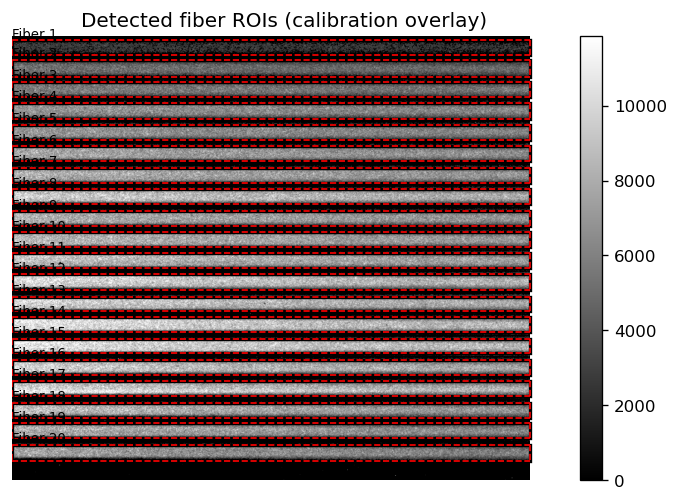

Extracted fibers: 20


In [11]:
from pathlib import Path

cal_folder = Path(CONFIG["CAL_FOLDER"])
lamp_csv = Path(CONFIG["LAMP_CSV"])
assert cal_folder.exists(), f"Calibration folder not found: {cal_folder}"
assert lamp_csv.exists(), f"Lamp CSV not found: {lamp_csv}"

spe_files = sorted(cal_folder.glob("*.spe"))
print(f"Found {len(spe_files)} calibration SPEs")

N_SKIP = 6
spe_files_used = spe_files[N_SKIP:] if len(spe_files) > N_SKIP else spe_files
print(f"Using {len(spe_files_used)} calibration SPEs")

# Pixels below this value are zeroed before stacking (edit as needed).
STACK_PIXEL_THRESHOLD = 2000  # counts

# IMPORTANT: use a pixel-wise MAX instead of SUM so fibers that appear in multiple SPEs
# only contribute from their brightest instance (prevents triple-counting).
stacked = None
for f in spe_files_used:
    img = load_spe_image(str(f))
    img = np.where(img < STACK_PIXEL_THRESHOLD, 0.0, img).astype(np.float64)
    stacked = img if stacked is None else np.maximum(stacked, img)

print("Stacked calibration image (max-stack):", stacked.shape, stacked.dtype)

fibers = extract_fiber_and_calibrate(
    stacked,
    lamp_csv_path=str(lamp_csv),
    sauvola_k=0.01,
    smooth_window=5,
    n_fibers=20,
    n_pixels=1024
 )

if not fibers:
    raise RuntimeError("No fibers detected from calibration overlay.")

# Step 1 plot (end): fiber ROIs on stacked calibration overlay
show_fiber_boxes(stacked, fibers, title="Detected fiber ROIs (calibration overlay)")
print("Extracted fibers:", len(fibers))

In [12]:
# Shared wavelength axis (from calibration) + photon energy at lambda0
lambda0_nm = float(CONFIG["lambda0_nm"])
wl_nm = np.asarray(fibers[0]["wavelength_nm"], dtype=float)

# Pixel/column index corresponding to lambda0 on the calibration wavelength axis
col_lambda0 = int(np.nanargmin(np.abs(wl_nm - lambda0_nm)))

E_ph = float(CONFIG["h"]) * float(CONFIG["c"]) / (lambda0_nm * 1e-9)

print("Shared wavelength axis")
print("  wl_nm[0], wl_nm[-1] =", float(wl_nm[0]), float(wl_nm[-1]))
print("  lambda0_nm =", lambda0_nm)
print("  col_lambda0 =", col_lambda0, "(wl=", float(wl_nm[col_lambda0]), "nm)")
print("  E_ph (J) =", E_ph)


Shared wavelength axis
  wl_nm[0], wl_nm[-1] = 226.654 232.726
  lambda0_nm = 229.7
  col_lambda0 = 513 (wl= 229.69890322580645 nm)
  E_ph (J) = 8.648001119499037e-19


## Preprocess helpers (shared)
Small helpers so both methods use the same wavelength selection and plotting utilities.

## Method A (campaign-style) — Step 1: peak-find at $\lambda_0$ → counts per fiber
This matches your updated campaign idea: at a single wavelength column (near 229.7 nm), find 20 spatial peaks corresponding to the 20 fibers/chords.

In [13]:
from shot_processing import extract_20_peaks_middle_column

# Use SPE image if available; otherwise use HDF5 image
img_A = img_spe if img_spe is not None else img_h5

# Method A Step 1: peak-find at the wavelength-column closest to lambda0
W = int(img_A.shape[1])
col_mid = W // 2
colA = int(col_lambda0) if "col_lambda0" in globals() else col_mid

# Roll image so the desired column becomes the middle column (lets us reuse repo helper)
shift = int(col_mid - colA)
img_A_roll = np.roll(img_A, shift=shift, axis=1)

A_counts_peak, A_y = extract_20_peaks_middle_column(
    img_A_roll,
    smooth_window=int(CONFIG["spatial_peak"].get("smooth_window", 12)),
    min_distance=int(CONFIG["spatial_peak"].get("min_distance", 35)),
    start_mult=float(CONFIG["spatial_peak"].get("start_mult", 0.6)),
    max_iter=int(CONFIG["spatial_peak"].get("max_iter", 40)),
    allow_trim=True,
 )
if A_counts_peak is None or A_y is None:
    raise RuntimeError("Method A: could not extract 20 peaks")

A_counts_peak = np.asarray(A_counts_peak, dtype=float)
A_y = np.asarray(A_y, dtype=int)

print("Method A Step 1: extracted 20 peak counts at lambda0")
print("  colA =", colA, "(wl=", float(wl_nm[colA]) if "wl_nm" in globals() else np.nan, "nm)")
print("  counts[0:5] =", A_counts_peak[:5])


Method A Step 1: extracted 20 peak counts at lambda0
  colA = 513 (wl= 229.69890322580645 nm)
  counts[0:5] = [ 2683.88888889  6784.88888889 14633.11111111 13077.22222222
  8500.22222222]


## Method A — Step 2: peak counts × multiplier at $\lambda_0$
Convert peak counts at $\lambda_0$ to irradiance using the per-fiber irradiance-per-count multiplier (evaluated at the same wavelength column), with the shared gate correction.

Loaded sxb_cal:
  type= <class 'numpy.ndarray'> shape= (4, 20) dtype= float64
  sxb_cal[3] shape= (20,)
Method A Step 2: campaign-scalar photon flux computed
  counts_cal_per_s[0:5] = [ 88.83678441 213.03100612 235.56331085 280.21240084 280.65738124]
  A0_photon_flux_raw[0:5] = [1.01952579e+28 1.07479697e+28 2.09631013e+28 1.57490610e+28
 1.02206925e+28]


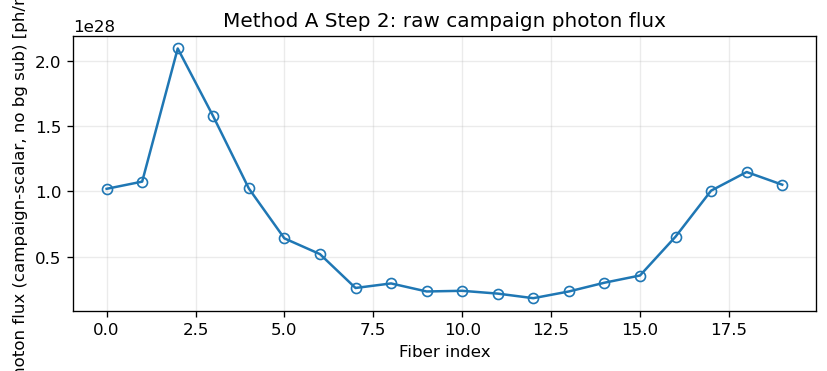

In [20]:
# Method A Step 2: campaign-scalar photon flux at lambda0 (SXB_Analysis.py procedure)
# Uses the campaign absolute calibration (sxb_cal.npy) rather than the per-fiber multiplier.

# Load campaign calibration array (produced by the DH3 absolute calibration workflow)
sxb_cal = np.load(CONFIG["SXB_CAL_NPY"], allow_pickle=True)

# Counts/s obtained from calibration at 229.7 nm (SXB_Analysis.py uses sxb_cal[3])
gate_cal_s = float(CONFIG["gate_cal_s"])  # ~21 s
counts_cal_per_s = np.asarray(sxb_cal[3], dtype=float) / gate_cal_s

print("Loaded sxb_cal:")
print("  type=", type(sxb_cal), "shape=", getattr(sxb_cal, "shape", None), "dtype=", getattr(sxb_cal, "dtype", None))
print("  sxb_cal[3] shape=", np.asarray(sxb_cal[3]).shape)

# Absolute irradiance at 229.7 nm from SXB_Analysis.py [uW/cm^2/nm]
Irr_abs_uW_cm2_nm = 6.3525963157828755

# Convert to W/m^2 (mirrors SXB_Analysis.py's convention of multiplying by lambda0_nm)
Irr_abs_W_m2 = Irr_abs_uW_cm2_nm * 1e-6 * 1e4 * float(CONFIG["lambda0_nm"])

# Counts/s obtained from experiment at target wavelength column (raw)
A_counts_exp_per_s_raw = np.asarray(A_counts_peak, dtype=float) / gate_exp_s

# Photon flux [photons/m^2/s] via campaign scalar calibration (raw, no bg subtraction)
A0_photon_flux_raw = ((A_counts_exp_per_s_raw / counts_cal_per_s) * Irr_abs_W_m2) / E_ph

print("Method A Step 2: campaign-scalar photon flux computed")
print("  counts_cal_per_s[0:5] =", np.asarray(counts_cal_per_s, dtype=float).ravel()[:5])
print("  A0_photon_flux_raw[0:5] =", np.asarray(A0_photon_flux_raw, dtype=float)[:5])

# Step 2 plot (end): Method A raw photon flux
plt.figure(figsize=(7, 3.2))
plt.plot(np.asarray(A0_photon_flux_raw, dtype=float), "o-", markerfacecolor="none")
plt.ylabel("Photon flux (campaign-scalar, no bg sub) [ph/m²/s]")
plt.xlabel("Fiber index")
plt.title("Method A Step 2: raw campaign photon flux")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## Method B (clean/ROI) — Step 2: shot extraction → calibrated fiber intensities
This follows `clean_testing_notebook.ipynb`: for each fiber ROI we threshold the illuminated region, background-subtract locally, collapse spatially by **mean**, apply the per-fiber irradiance-per-count multiplier, then integrate to one calibrated scalar per fiber.

No edge-chord subtraction is applied in Method B.

c:\Users\elyse\Downloads\Python\Zap\spectroscopy\regions_processing.py:628: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  illum_mask = remove_small_objects(illum_mask, min_size=min_area)


Method B Step 2:
  B_photon_flux_int[0:5]     = [1.23423932e+27 1.67491408e+27 3.35172255e+27 3.44322378e+27
 2.95936510e+27]
  B_photon_flux_lambda0[0:5] = [6.78220212e+27 8.80759844e+27 1.55025046e+28 9.03131464e+27
 2.42888748e+27]
  median(A/B) at lambda0 only = 3.9087517585030076
  median(A/B) vs integrated B = 2.84971960704038


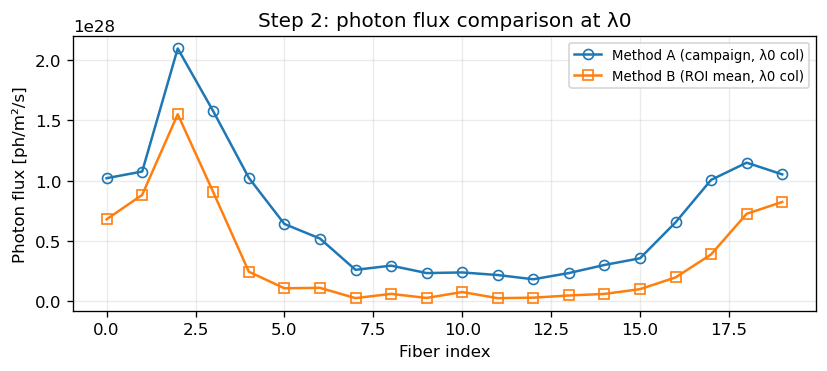

In [ ]:
# Method B Step 2: shot extraction (match clean_testing_notebook)
B_result = extract_real_image_fiber_intensities(
    img=img_h5,
    fibers=fibers,
    min_area=int(CONFIG["roi"]["min_area"]),
    sauvola_window=int(CONFIG["roi"]["sauvola_window"]),
    sauvola_k=float(CONFIG["roi"]["sauvola_k"]),
    profile_half_height=int(CONFIG["roi"]["profile_half_height"]),
    spatial_collapse=str(CONFIG["roi"]["spatial_collapse"]),
)

# This is the "clean notebook" output: one integrated intensity per fiber (no edge subtraction)
B_fiber_intensities_uW_cm2_raw = np.asarray(B_result["fiber_intensities_uW_cm2"], dtype=float)
B_fiber_intensities_uW_cm2 = B_fiber_intensities_uW_cm2_raw * gate_corr

# Convert Method B calibrated fiber intensities -> photon flux chord profile
conv_uWcm2_to_Wm2 = 1e-6 * 1e4
B_photon_flux = (np.asarray(B_fiber_intensities_uW_cm2, dtype=float) * conv_uWcm2_to_Wm2) / E_ph  # ph/m^2/s

# Step 2 plot (end): Method B photon flux
plt.figure(figsize=(7, 3.2))
plt.plot(B_photon_flux, "o-", markerfacecolor="none")
plt.ylabel("Photon flux (gate-corrected) [ph/m²/s]")
plt.xlabel("Fiber index")
plt.title("Method B Step 2: calibrated fiber intensities")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## Method A — Step 3: edge-chord subtraction (on irradiance)
Campaign-style background subtraction: average the edge chords (first 4 + last 4) and subtract **half** that mean from every chord (applied here to Method A only).

Method A Step 3: edge subtraction applied (on photon flux)
  A_bg = 1.2028859151614346e+28
  A_photon_flux[0:5] = [4.18082828e+27 4.73354013e+27 1.49486717e+28 9.73463141e+27
 4.20626294e+27]


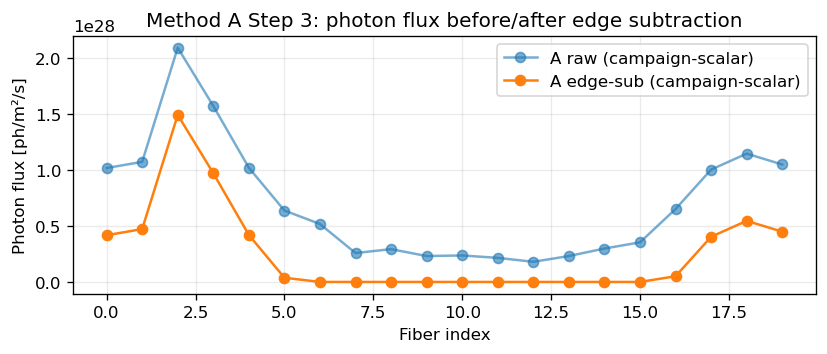

In [21]:
edge = np.array(CONFIG["edge_chords"], dtype=int)

# Background subtraction (campaign-style): subtract half the mean edge-chord photon flux
A_bg = float(np.nanmean(np.asarray(A0_photon_flux_raw, dtype=float)[edge]))
A_photon_flux = np.asarray(A0_photon_flux_raw, dtype=float) - 0.5 * A_bg
A_photon_flux = np.clip(A_photon_flux, 0.0, None)

print("Method A Step 3: edge subtraction applied (on photon flux)")
print("  A_bg =", A_bg)
print("  A_photon_flux[0:5] =", np.asarray(A_photon_flux, dtype=float)[:5])

# Step 3 plot (end): Method A photon flux before/after edge subtraction
plt.figure(figsize=(7, 3.2))
plt.plot(A0_photon_flux_raw, "o-", alpha=0.6, label="A raw (campaign-scalar)")
plt.plot(A_photon_flux, "o-", label="A edge-sub (campaign-scalar)")
plt.title("Method A Step 3: photon flux before/after edge subtraction")
plt.xlabel("Fiber index")
plt.ylabel("Photon flux [ph/m²/s]")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


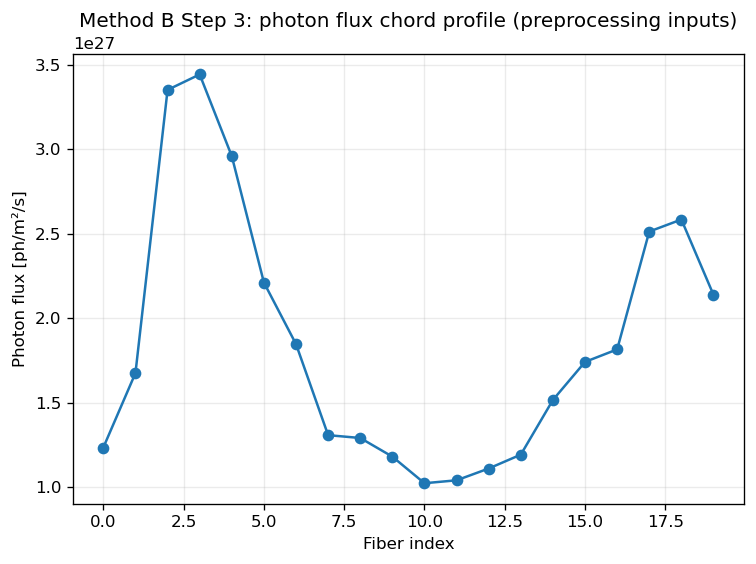

Method B Step 3: Abel inversion inputs
  side = right
  kept chords = [11.8        10.48888889  9.17777778  7.86666667  6.55555556  5.24444444
  3.93333333  2.62222222  1.31111111  0.        ]
Method B Step 3: Abel inversion shell emissivities (ph/m^3/s, up to geometry scaling)
  cond(L) = 3709.138634929967
  shell[00] = 9.22103e+25
  shell[01] = 8.03887e+25
  shell[02] = 5.05565e+25
  shell[03] = 0
  shell[04] = 3.83032e+25


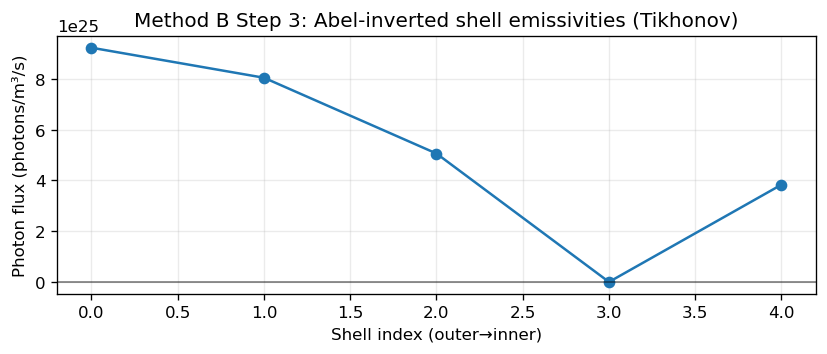

In [ ]:
# Method B Step 3: Abel inversion on photon flux (clean_testing_notebook-style)
from shot_processing import ascending_suffix, build_L_onion, tikhonov_inversion

if B_fiber_intensities_uW_cm2.size != 20:
    raise ValueError(f"Expected 20 fibers for Method B, got {B_fiber_intensities_uW_cm2.size}")

# Convert Method B calibrated fiber intensities -> photon flux chord profile
conv_uWcm2_to_Wm2 = 1e-6 * 1e4
B_photon_flux = (np.asarray(B_fiber_intensities_uW_cm2, dtype=float) * conv_uWcm2_to_Wm2) / E_ph  # ph/m^2/s

plt.plot(B_photon_flux, "o-")
plt.title("Method B Step 3: photon flux chord profile (preprocessing inputs)")
plt.xlabel("Fiber index")
plt.ylabel("Photon flux [ph/m²/s]")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Abel inversion parameters (match clean_testing_notebook defaults)
USE_RIGHT_SIDE_ONLY = True
ABEL_LAM = 1.0
ABEL_W_INNER = 1.0
ABEL_R_MM = 11.8
ABEL_ELEC_RAD_MM = 0.4
ABEL_N_SHELLS = 5
ABEL_USE_N_CHORDS = 5  # use 5 center-most chords after preprocessing

# Impact parameters (one side): outer -> center
b_raw = np.linspace(float(ABEL_R_MM), 0.0, 10)

# Reorder to match analysis_notebook / clean_testing_notebook convention
I_left = B_photon_flux[:10]
I_right = np.flip(B_photon_flux[10:])
I_use = I_right if USE_RIGHT_SIDE_ONLY else I_left

# Preprocess: keep a monotone-ish suffix near the center + electrode crop
b_keep, I_keep = ascending_suffix(
    b_raw,
    I_use,
    elec_rad=float(ABEL_ELEC_RAD_MM),
    inner_chord_num=0,
 )

b_keep = np.asarray(b_keep, dtype=float)
I_keep = np.asarray(I_keep, dtype=float)
print("Method B Step 3: Abel inversion inputs")
print("  side =", "right" if USE_RIGHT_SIDE_ONLY else "left")
print("  kept chords =", b_keep)

B_abel_eps = None
B_abel_diag = None

if b_keep.size < int(ABEL_USE_N_CHORDS):
    print(
        "Abel inversion skipped: only ", int(b_keep.size), " usable chord(s) after preprocessing (need ", int(ABEL_USE_N_CHORDS), ").",
        sep="",
    )
else:
    # Use ONLY the N chords closest to center (smallest b), in outer->center order
    b_used = b_keep[-int(ABEL_USE_N_CHORDS):]
    I_used = I_keep[-int(ABEL_USE_N_CHORDS):]

    # Shell edges (mm), outer -> inner
    edges = np.linspace(float(ABEL_R_MM), float(ABEL_ELEC_RAD_MM) - 0.4, int(ABEL_N_SHELLS) + 1)
    L = build_L_onion(b_used, edges, elec_rad=float(ABEL_ELEC_RAD_MM))

    eps_rec = tikhonov_inversion(L, I_used, lam=float(ABEL_LAM), w_inner=float(ABEL_W_INNER))
    B_abel_eps = np.asarray(eps_rec, dtype=float)
    B_abel_diag = {
        "b_used": np.asarray(b_used, dtype=float),
        "I_used": np.asarray(I_used, dtype=float),
        "L": np.asarray(L, dtype=float),
        "edges": np.asarray(edges, dtype=float),
    }

    print("Method B Step 3: Abel inversion shell emissivities (ph/m^3/s, up to geometry scaling)")
    print("  cond(L) =", float(np.linalg.cond(B_abel_diag["L"])))
    for i, v in enumerate(B_abel_eps):
        print(f"  shell[{i:02d}] = {v:.6g}")

    # Step 3 plot (end): recovered shell emissivities
    plt.figure(figsize=(7, 3.2))
    plt.plot(B_abel_eps, "o-")
    plt.axhline(0, color="k", lw=1, alpha=0.5)
    plt.title("Method B Step 3: Abel-inverted shell emissivities (Tikhonov)")
    plt.xlabel("Shell index (outer→inner)")
    plt.ylabel("Photon flux (photons/m³/s)")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


## Step 4: photon flux + $S/XB$ + erosion flux
We compute photon flux from the calibrated signals using $E_\gamma = hc/\lambda_0$ and then apply $\Gamma = 4\pi\,(S/XB)\,\Phi_\gamma$.
If DHI profiles are unavailable, this falls back to a constant $S/XB$.

DHI profile unavailable; using constant SXB. Error: MdsIpException('Error connecting to 172.25.35.142')
SXB:
  used_profile = False
  sxb range = 118.91357620452894 .. 118.91357620452894


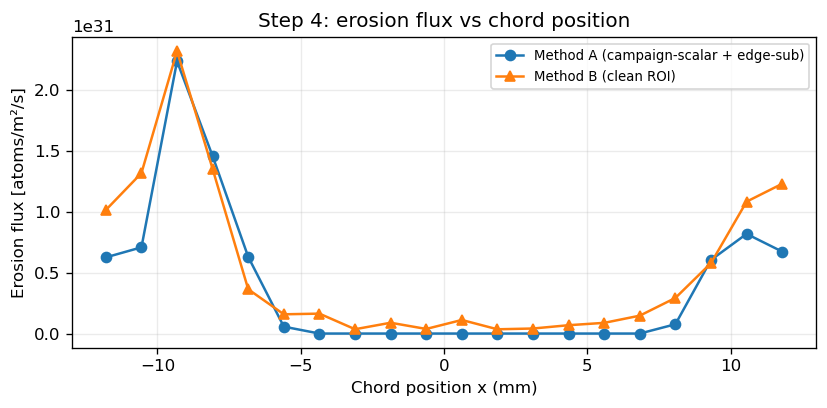

In [25]:
from read_sxb_class import read_sxb

# Chord positions (mm) consistent with SXB_Analysis.py
x_mm = np.linspace(-23.6 / 2, 23.6 / 2, 20)
r_m = np.abs(x_mm) * 1e-3

# Get SXB per chord from expanded Te/ne profiles (try DHI; fallback to constant)
sxb_vals = read_sxb("C-III")
SXB_CONST_Te_eV = 1000.0
SXB_CONST_ne_m3 = 2e23
sxb_const = float(sxb_vals.get_sxb(SXB_CONST_Te_eV, SXB_CONST_ne_m3))
sxb_chords = np.full(20, sxb_const, dtype=float)

used_profile = False
try:
    import matplotlib.pyplot as plt
    from read_dhi_mds import dhi_profiles
    # NOTE: this may require MDSplus connectivity; keep try/except
    figs_before = set(plt.get_fignums())
    r_dhi, ne_dhi, _, te_dhi, *_ = dhi_profiles("lateral", radius=0.003)
    # Close any figures created by dhi_profiles so Step 4 only shows the final plot
    for fnum in set(plt.get_fignums()) - figs_before:
        plt.close(fnum)

    r_dhi = np.asarray(r_dhi, dtype=float)
    ne_dhi = np.asarray(ne_dhi, dtype=float)
    te_dhi = np.asarray(te_dhi, dtype=float)
    order = np.argsort(r_dhi)
    r_dhi = r_dhi[order]
    ne_dhi = ne_dhi[order]
    te_dhi = te_dhi[order]
    ne_ch = np.interp(r_m, r_dhi, ne_dhi, left=np.nan, right=np.nan)
    te_ch = np.interp(r_m, r_dhi, te_dhi, left=np.nan, right=np.nan)
    for i in range(20):
        if np.isfinite(ne_ch[i]) and np.isfinite(te_ch[i]) and ne_ch[i] > 0 and te_ch[i] > 0:
            sxb_chords[i] = float(sxb_vals.get_sxb(float(te_ch[i]), float(ne_ch[i])))
    used_profile = True
except Exception as e:
    print("DHI profile unavailable; using constant SXB. Error:", repr(e))

print("SXB:")
print("  used_profile =", used_profile)
print("  sxb range =", float(np.nanmin(sxb_chords)), "..", float(np.nanmax(sxb_chords)))

# Method A photon flux: prefer edge-subtracted (Step 3), else raw (Step 2)
if "A_photon_flux" in globals():
    A_flux_use = np.asarray(A_photon_flux, dtype=float)
elif "A0_photon_flux_raw" in globals():
    A_flux_use = np.asarray(A0_photon_flux_raw, dtype=float)
else:
    raise RuntimeError("Method A photon flux not found. Run Method A Step 2 (and Step 3 if desired) first.")

# Method B photon flux (computed in Step 2)
B_flux_use = np.asarray(B_photon_flux, dtype=float)

# Erosion flux (atoms/m^2/s)
A_erosion_flux = 4.0 * np.pi * sxb_chords * A_flux_use
B_erosion_flux = 4.0 * np.pi * sxb_chords * B_flux_use

# Step 4 plot (end): erosion flux vs chord position
plt.figure(figsize=(7, 3.5))
plt.plot(x_mm, A_erosion_flux, "o-", label="Method A (campaign-scalar + edge-sub)")
plt.plot(x_mm, B_erosion_flux, "^-", label="Method B (clean ROI)")
plt.xlabel("Chord position x (mm)")
plt.ylabel("Erosion flux [atoms/m²/s]")
plt.title("Step 4: erosion flux vs chord position")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
